In [34]:
# EDA for BDAPPV solar panel segmentation dataset

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Make plots show inline in the notebook
%matplotlib inline

# Set up paths
PROJECT_ROOT = Path.cwd().parent  # parent of notebooks/ is the project root
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "bdappv"
GOOGLE_IMG_DIR = DATA_DIR / "google" / "img"
GOOGLE_MASK_DIR = DATA_DIR / "google" / "mask"

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Images dir exists:", GOOGLE_IMG_DIR.exists())
print("Masks dir exists:", GOOGLE_MASK_DIR.exists())

Project root: E:\All Projects\Pycharm\solar-panel-segmentation
Data dir: E:\All Projects\Pycharm\solar-panel-segmentation\data\raw\bdappv
Images dir exists: True
Masks dir exists: True


In [35]:
# Cell 2: Load and display one image and its mask

# Get the list of mask filenames. We iterate over masks (not images) because
# every mask has a corresponding image, but not every image has a mask.
mask_files = sorted(os.listdir(GOOGLE_MASK_DIR))
print(f"Total masks available: {len(mask_files)}")
print(f"First mask filename: {mask_files[0]}")

# Pick the first mask and load both image and mask
sample_filename = mask_files[0]
image_path = GOOGLE_IMG_DIR / sample_filename
mask_path = GOOGLE_MASK_DIR / sample_filename

# Load with Pillow
image = Image.open(image_path)
mask = Image.open(mask_path)

# Print basic info about both
print("\nImage info:")
print(f"  Size: {image.size}")        # (width, height)
print(f"  Mode: {image.mode}")        # color mode like 'RGB'
print(f"  Format: {image.format}")    # file format like 'PNG'

print("\nMask info:")
print(f"  Size: {mask.size}")
print(f"  Mode: {mask.mode}")
print(f"  Format: {mask.format}")

Total masks available: 13303
First mask filename: AABCN78E1YHCWW.png

Image info:
  Size: (400, 400)
  Mode: P
  Format: PNG

Mask info:
  Size: (400, 400)
  Mode: L
  Format: PNG


In [36]:
# Cell 3: Convert to proper formats and verify

# Convert image to RGB (some images in dataset are palette-mode P)
image_rgb = image.convert("RGB")
print("After convert to RGB:")
print(f"  Mode: {image_rgb.mode}")
print(f"  Size: {image_rgb.size}")

# Convert image and mask to numpy arrays so we can inspect pixel values
image_array = np.array(image_rgb)
mask_array = np.array(mask)

print(f"\nImage array shape: {image_array.shape}")     # (H, W, 3) for RGB
print(f"Image array dtype: {image_array.dtype}")        # should be uint8
print(f"Image pixel range: [{image_array.min()}, {image_array.max()}]")

print(f"\nMask array shape: {mask_array.shape}")        # (H, W) for grayscale
print(f"Mask array dtype: {mask_array.dtype}")
print(f"Mask pixel range: [{mask_array.min()}, {mask_array.max()}]")
print(f"Unique values in mask: {np.unique(mask_array)}")

After convert to RGB:
  Mode: RGB
  Size: (400, 400)

Image array shape: (400, 400, 3)
Image array dtype: uint8
Image pixel range: [0, 254]

Mask array shape: (400, 400)
Mask array dtype: uint8
Mask pixel range: [0, 255]
Unique values in mask: [  0 255]


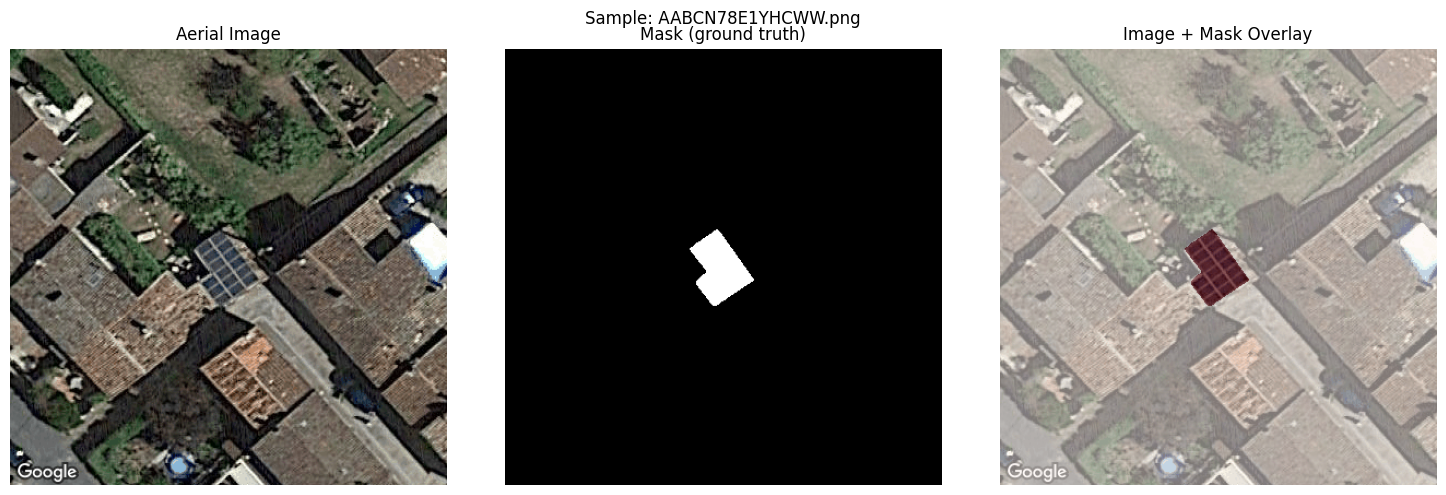

In [37]:
# Cell 4: Display the image and mask side by side

# Create a figure with 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: the image
axes[0].imshow(image_array)
axes[0].set_title("Aerial Image")
axes[0].axis("off")  # hide axis ticks

# Subplot 2: the mask
axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("Mask (ground truth)")
axes[1].axis("off")

# Subplot 3: the image with the mask overlaid in red
# This is the most useful visualization: shows where panels actually are
axes[2].imshow(image_array)
axes[2].imshow(mask_array, cmap="Reds", alpha=0.5)  # red overlay, 50% transparent
axes[2].set_title("Image + Mask Overlay")
axes[2].axis("off")

plt.suptitle(f"Sample: {sample_filename}", fontsize=12)
plt.tight_layout()
plt.show()

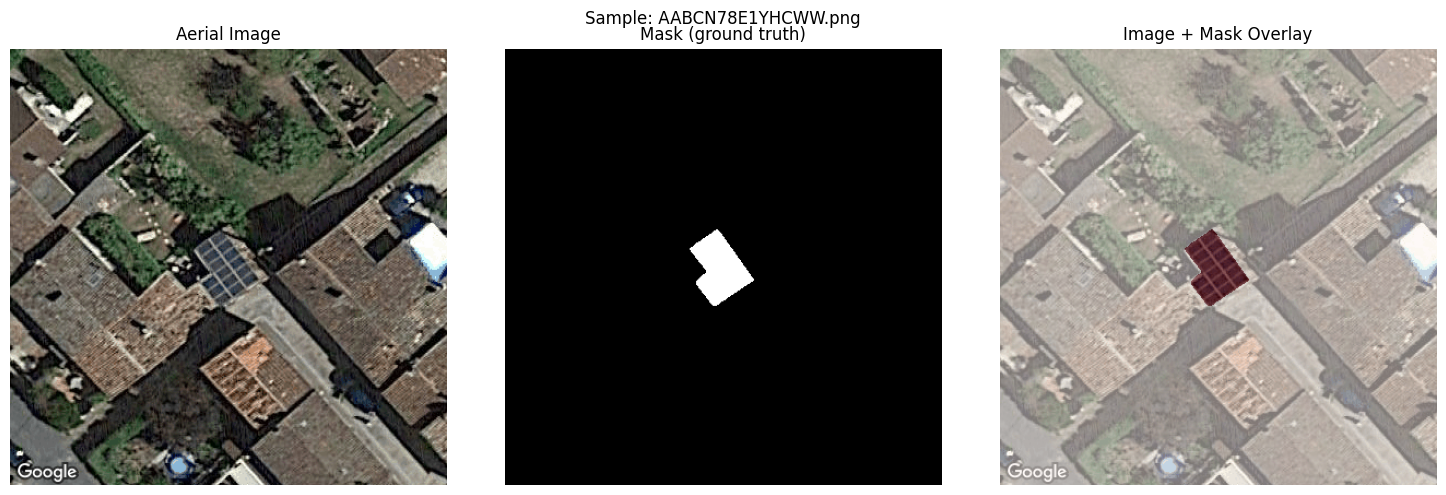

In [39]:
# Cell 4: Display the image and mask side by side

# Create a figure with 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: the image
axes[0].imshow(image_array)
axes[0].set_title("Aerial Image")
axes[0].axis("off")  # hide axis ticks

# Subplot 2: the mask
axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("Mask (ground truth)")
axes[1].axis("off")

# Subplot 3: the image with the mask overlaid in red
# This is the most useful visualization: shows where panels actually are
axes[2].imshow(image_array)
axes[2].imshow(mask_array, cmap="Reds", alpha=0.5)  # red overlay, 50% transparent
axes[2].set_title("Image + Mask Overlay")
axes[2].axis("off")

plt.suptitle(f"Sample: {sample_filename}", fontsize=12)
plt.tight_layout()
plt.show()

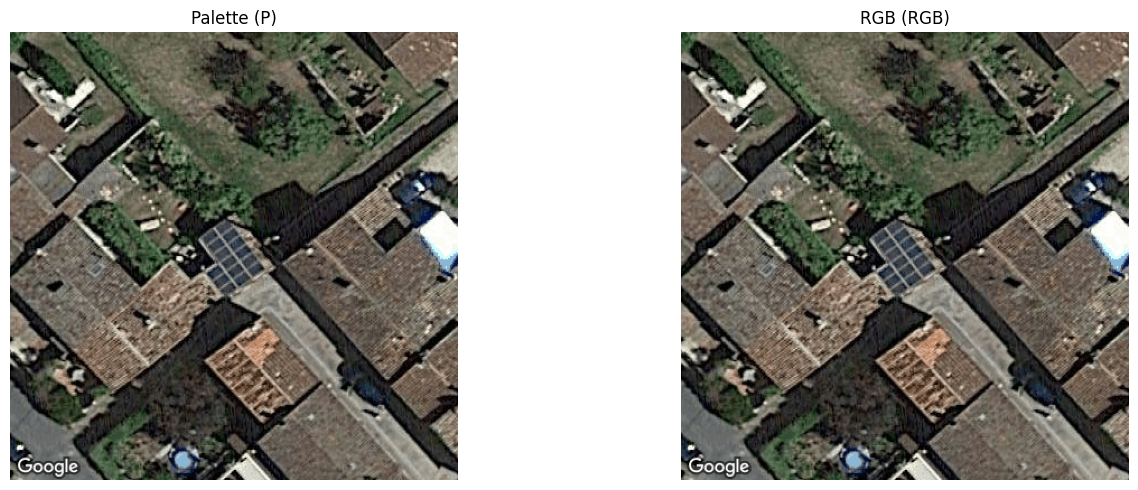

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(image)        # palette mode
axes[0].set_title(f"Palette ({image.mode})")
axes[0].axis("off")  # hide axis ticks

axes[1].imshow(image_array)    # RGB mode
axes[1].set_title(f"RGB ({image_rgb.mode})")
axes[1].axis("off")  # hide axis ticks

plt.tight_layout()

plt.show()

In [49]:
from tqdm import tqdm

# collect stats for every mask/image pair
image_sizes = []
mask_sizes = []
panel_pixel_percentages = []
missing_images = []

mask_files = sorted(os.listdir(GOOGLE_MASK_DIR))
print(f"Scanning {len(mask_files)} masks...")

for mask_filename in tqdm(mask_files):
    mask_path = GOOGLE_MASK_DIR / mask_filename
    image_path = GOOGLE_IMG_DIR / mask_filename

    # skip if image is missing (shouldn't happen but just in case)
    if not image_path.exists():
        missing_images.append(mask_filename)
        continue

    mask = Image.open(mask_path)
    mask_arr = np.array(mask)
    mask_sizes.append(mask.size)

    # only need image size, not pixel data, so use a context manager
    with Image.open(image_path) as img:
        image_sizes.append(img.size)

    # threshold at 127 in case masks have intermediate values from compression
    panel_pixel_count = (mask_arr > 127).sum()
    panel_pixel_percentages.append(panel_pixel_count / mask_arr.size)

print(f"\nDone. Stats collected for {len(mask_sizes)} samples.")
print(f"Missing images: {len(missing_images)}")

Scanning 13303 masks...


100%|██████████| 13303/13303 [08:10<00:00, 27.14it/s]


Done. Stats collected for 13303 samples.
Missing images: 0


In [59]:
# Cell: dataset statistics and visualizations

# Convert lists to numpy arrays for easy analysis
panel_percentages = np.array(panel_pixel_percentages)
image_widths = np.array([s[0] for s in image_sizes])
image_heights = np.array([s[1] for s in image_sizes])

# Summary statistics

print("IMAGE SIZE STATISTICS\n")

print(f"Image widths:  min={image_widths.min()}, max={image_widths.max()}, unique={np.unique(image_widths)}")
print(f"Image heights: min={image_heights.min()}, max={image_heights.max()}, unique={np.unique(image_heights)}")


print("\nPANEL PIXEL PERCENTAGE STATISTICS\n")

print(f"Mean panel coverage: {panel_percentages.mean() * 100:.2f}%")
print(f"Median panel coverage: {np.median(panel_percentages) * 100:.2f}%")
print(f"Min panel coverage: {panel_percentages.min() * 100:.2f}%")
print(f"Max panel coverage: {panel_percentages.max() * 100:.2f}%")
print(f"Std deviation: {panel_percentages.std() * 100:.2f}%")

# How many masks are nearly empty (less than 0.1% panel)?
nearly_empty = (panel_percentages < 0.001).sum()
print(f"\nMasks with < 0.1% panel pixels: {nearly_empty}")

# How many masks are dominated by panel (more than 50% panel)?
dominated = (panel_percentages > 0.5).sum()
print(f"Masks with > 50% panel pixels: {dominated}")

IMAGE SIZE STATISTICS

Image widths:  min=400, max=400, unique=[400]
Image heights: min=400, max=400, unique=[400]

PANEL PIXEL PERCENTAGE STATISTICS

Mean panel coverage: 1.85%
Median panel coverage: 1.27%
Min panel coverage: 0.25%
Max panel coverage: 68.12%
Std deviation: 2.64%

Masks with < 0.1% panel pixels: 0
Masks with > 50% panel pixels: 2


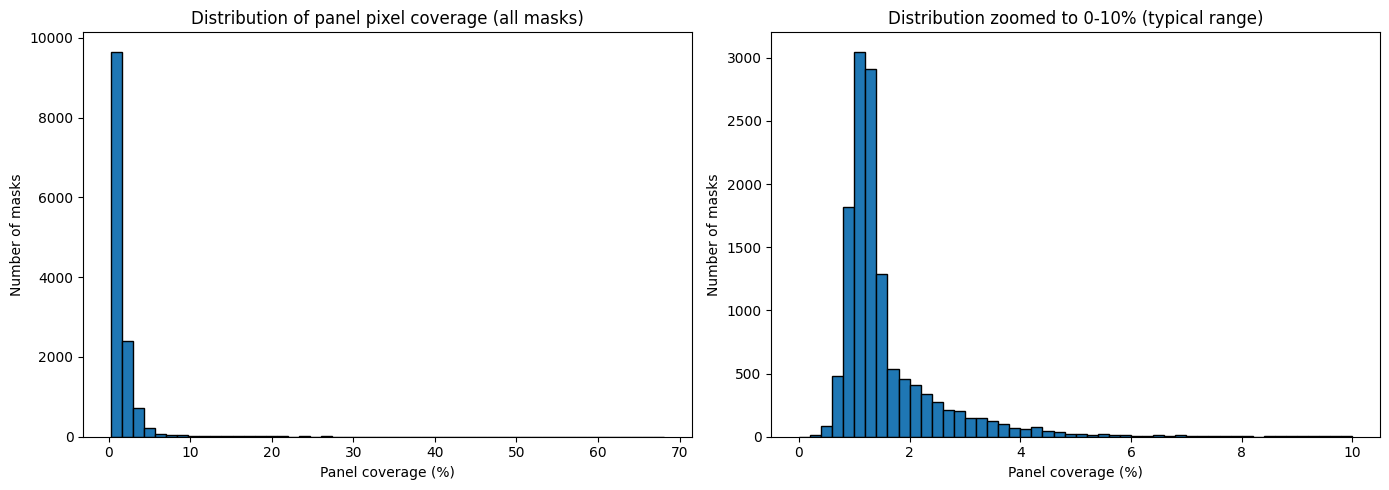

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full range view
axes[0].hist(panel_percentages * 100, bins=50, edgecolor='black')
axes[0].set_xlabel('Panel coverage (%)')
axes[0].set_ylabel('Number of masks')
axes[0].set_title('Distribution of panel pixel coverage (all masks)')

# zoom to where most samples are
axes[1].hist(panel_percentages * 100, bins=50, range=(0, 10), edgecolor='black')
axes[1].set_xlabel('Panel coverage (%)')
axes[1].set_ylabel('Number of masks')
axes[1].set_title('Distribution zoomed to 0-10% (typical range)')

plt.tight_layout()
plt.show()

In [61]:
import sys
import torch
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import SolarPanelDataset

dataset = SolarPanelDataset(GOOGLE_IMG_DIR, GOOGLE_MASK_DIR)

print(f"Dataset size: {len(dataset)}")

image, mask = dataset[0]
print(f"Image: shape={tuple(image.shape)}, dtype={image.dtype}, range=[{image.min():.3f}, {image.max():.3f}]")
print(f"Mask:  shape={tuple(mask.shape)}, dtype={mask.dtype}, unique={torch.unique(mask).tolist()}")

Dataset size: 13303
Image: shape=(3, 400, 400), dtype=torch.float32, range=[0.000, 0.996]
Mask:  shape=(400, 400), dtype=torch.float32, unique=[0.0, 1.0]


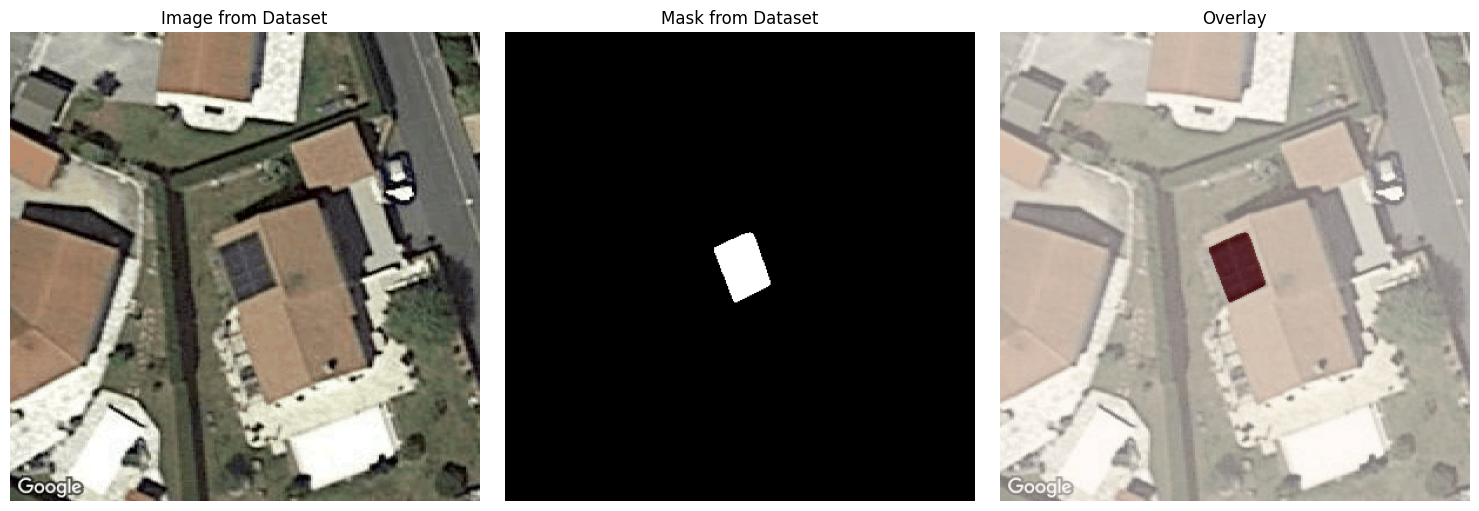

In [65]:
# Cell: visual sanity check on Dataset output

image, mask = dataset[63]  # pick a different sample for variety

# convert (C, H, W) tensor back to (H, W, C) numpy for display
image_display = image.permute(1, 2, 0).numpy()
mask_display = mask.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_display)
axes[0].set_title("Image from Dataset")
axes[0].axis("off")

axes[1].imshow(mask_display, cmap="gray")
axes[1].set_title("Mask from Dataset")
axes[1].axis("off")

axes[2].imshow(image_display)
axes[2].imshow(mask_display, cmap="Reds", alpha=0.5)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [66]:
# Cell: test DataLoader

from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,  # use 0 on Windows to avoid multiprocessing issues
)

# grab one batch
batch_images, batch_masks = next(iter(loader))

print(f"Batch images: shape={tuple(batch_images.shape)}, dtype={batch_images.dtype}")
print(f"Batch masks:  shape={tuple(batch_masks.shape)}, dtype={batch_masks.dtype}")
print(f"Number of batches per epoch: {len(loader)}")

Batch images: shape=(4, 3, 400, 400), dtype=torch.float32
Batch masks:  shape=(4, 400, 400), dtype=torch.float32
Number of batches per epoch: 3326


In [2]:
import torch

In [3]:
from src.training.losses import build_loss, compute_iou

loss_fn = build_loss()
print(f"Loss function: {loss_fn}")

fake_logits = torch.randn(2, 1, 400, 400)
fake_mask = (torch.rand(2, 400, 400) > 0.5).float()

loss_value = loss_fn(fake_logits, fake_mask)
iou_value = compute_iou(fake_logits, fake_mask)

print(f"Loss: {loss_value.item():.4f}")
print(f"IoU:  {iou_value:.4f}")


Loss function: DiceLoss()
Loss: 0.5010
IoU:  0.3329


In [ ]:
from pathlib import Path
from src.training.train import train

# absolute path to the google subset
data_dir = Path("E:/All Projects/Pycharm/solar-panel-segmentation/data/raw/bdappv/google")

print(f"Data dir exists: {data_dir.exists()}")

train(
    data_dir=data_dir,
    epochs=1,
    batch_size=2,
    device="auto",
)

Data dir exists: True
Training on: cpu
Dataset split: 11308 train, 1995 val
